# Homework 1
Univariate linear regression with gradient descent and logistic regression

## 1 - Univariate linear regression with gradient descent

**Step 1**  
I calculated the derivatives of L with respect to w0 and w1.  
I got -2 and -2x.

**Step 2**  
I will write an algorithm which can update the weights (w0, w1) by going in the opposite direction of the gradient.

In [1]:
def predict(w0, w1, x):
    return w0 + w1 * x

In [ ]:
def calculate_gradient(x, y, w0, w1):
    y_pred = predict(w0, w1, x)
    L1 = 1/len(x) * (sum(-2 * (y - (y_pred)))) # I got -2 from step 1
    L2 = 1/len(x) * (sum(-2 * x * (y - (y_pred)))) # I got -2x from step 1
    return (L1, L2)

In [3]:
def update(x, y, w0, w1, lr):
    L1, L2 = calculate_gradient(x, y, w0, w1)
    w0 -= lr * L1
    w1 -= lr * L2
    return w0, w1

In [4]:
def loop(x, y, it, lr):
    w0, w1 = 0, 0

    for i in range(it):
        w0, w1 = update(x, y, w0, w1, lr)

    return w0, w1

In [5]:
import numpy as np

data = np.loadtxt('unilinear.csv', delimiter=',', skiprows=1)
x = data[:, 0]
y = data[:, 1]

w0, w1 = loop(x, y, it=40, lr=0.1)

print(w0, w1)

6.155614169309017 5.300224937809824


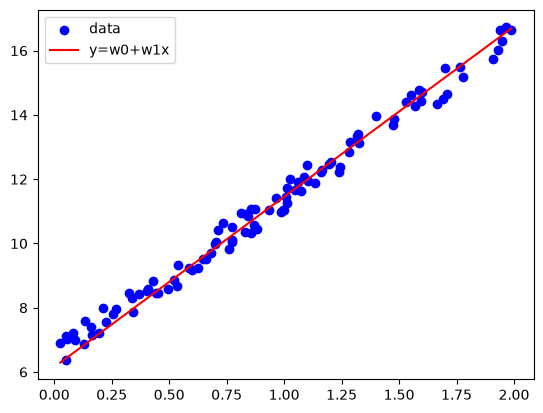

In [6]:
import matplotlib.pyplot as plt

x_sorted = np.sort(x)
y_pred = predict(w0, w1, x_sorted)

plt.scatter(x, y, color='blue', label='data')
plt.plot(x_sorted, y_pred, color='red', label='y=w0+w1x')
plt.legend()
plt.show()

## Computing exact closed form solution using Moore-Penrose

In [7]:
matrix = np.column_stack((np.ones_like(x), x))

pinv = np.linalg.pinv(matrix)

w0_exact, w1_exact = pinv.dot(y)

print(w0_exact, w1_exact)

6.454787089540192 5.021290388929582


In [8]:
print(abs(w0-w0_exact), abs(w1-w1_exact))

0.29917292023117437 0.2789345488802413


In [25]:
w0_hi_it, w1_hi_it = loop(x, y, it=400, lr=0.1)
print(abs(w0_hi_it-w0_exact), abs(w1_hi_it-w1_exact))


9.23694885912596e-06 8.612090707238451e-06


In [14]:
lrs = [0.0001, 0.001, 0.01, 0.1, 1.0]

for lr in lrs:
    w0_lr, w1_lr = loop(x, y, it=40, lr=lr)
    print(f"{lr}: {float(abs(w0_lr-w0_exact)), float(abs(w1_lr-w1_exact))}")

0.0001: (6.366865164896913, 4.9291512749338295)
0.001: (5.633396888179292, 4.161816599573654)
0.01: (1.9340724723559424, 0.3773230704525261)
0.1: (0.29917292023117437, 0.2789345488802413)
1.0: (4.702128935036877e+19, 5.043296220380709e+19)


Learning rate refers to the step size of the steps we take in gradient descent.  
Too big of a learning rate jumps over the local minima, too small of a learning rate never reaches it. A small learning rate can reach the local minima if the number of iterations is high enough.